# pytorch workflow

its similar to how we build models in ml project but using pytorch framework and neural neural network's building blocks

In [1]:
what_were_covering = {1:"data (preparing and loading)",
                      2:'build model',
                      3:'fitting the model to data(traning)',
                      4:'makin prediction and evaluating the model(inference)',
                      5:'saving and loadin the model',
                      6:'putting it all together'}
what_were_covering


{1: 'data (preparing and loading)',
 2: 'build model',
 3: 'fitting the model to data(traning)',
 4: 'makin prediction and evaluating the model(inference)',
 5: 'saving and loadin the model',
 6: 'putting it all together'}

In [2]:
import torch
from torch import nn  #nn contains all the building block of neural network
import matplotlib.pyplot as plt

torch.__version__

'2.7.0+cpu'

## 1. data (preparin and loading)

Data can be almost anything... in machine learning.

* Excel spreadsheet
* Images of any kind
* Videos (YouTube has lots of data...)
* Audio like songs or podcasts
* DNA
* Text

Machine learning is a game of two parts:

1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation.

To showcase this, let's create some *known* data using the linear regression formula.

We'll use a linear regression formula to make a straight line with known parameters

 formula * Y = wX + b*

In [3]:
weight = 0.6
bias = 0.2

start = 0
end = 2
step = 0.05

X = torch.arange(start,end,step).unsqueeze(dim=1)
Y = weight * X + bias

X[:10],Y[:10]

(tensor([[0.0000],
         [0.0500],
         [0.1000],
         [0.1500],
         [0.2000],
         [0.2500],
         [0.3000],
         [0.3500],
         [0.4000],
         [0.4500]]),
 tensor([[0.2000],
         [0.2300],
         [0.2600],
         [0.2900],
         [0.3200],
         [0.3500],
         [0.3800],
         [0.4100],
         [0.4400],
         [0.4700]]))

In [4]:
len(X),len(Y)

(40, 40)

## spliting data into training and testing split

let's create a training and testing split with our data

In [5]:
#create a train/test split

train_split = int(0.8*len(X))

X_train,Y_train = X[:train_split], Y[:train_split]
X_test,Y_test = X[train_split:], Y[train_split:]

len(X_train),len(Y_train),len(X_test),len(Y_test)

(32, 32, 8, 8)

when we need to undrstand the data all we do is * visualize,visualize,visualize...!*

In [6]:
def plot_prediction(
    train_data = X_train,
    train_labels =Y_train,
    test_data = X_test,
    test_labels = Y_test,
    predictions = None):

  plt.figure(figsize=(6,6))
#trainig data in yellow
  plt.scatter(train_data, train_labels, s=4,c="purple",label="training data")
#testing data in orange
  plt.scatter(test_data, test_labels,s=4,c="orange",label="testing data")

  if predictions is not None:
    plt.scatter(test_data,predictions, c="r", s=4, label="predictions")
  plt.legend(prop={"size":14});

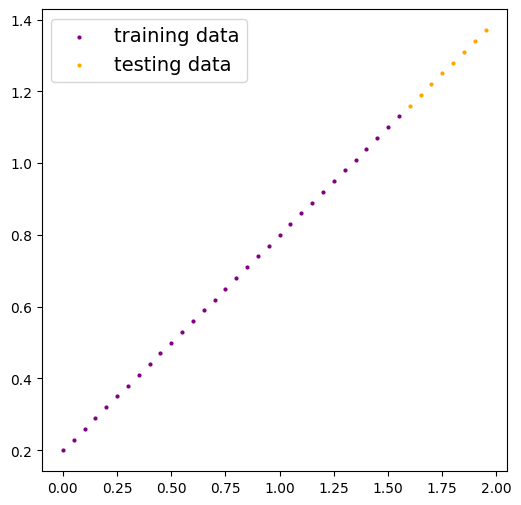

In [7]:
plot_prediction();

##2.build model

our first pytorch model...

let"s do it!!


In [8]:
import torch
from torch import nn
# linear regression model class
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    #model parameters
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))

    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))
  def forward(self,X:torch.tensor) -> torch.tensor:
    return self.weights*X + self.bias

### PyTorch model building essentials

* torch.nn – contains all of the buildings for computational graphs  
  (a neural network can be considered a computational graph)

* torch.nn.Parameter – what parameters should our model try and learn,  
  often a PyTorch layer from torch.nn will set these for us

* torch.nn.Module – The base class for all neural network modules,  
  if you subclass it, you should overwrite forward()

* torch.optim – this where the optimizers in PyTorch live,  
  they will help with gradient descent

* def forward() - all nn.modules sybclasses require you to overwrite forward(), this method defines what happens in the forward computation.

###to check the content of our pytorch model

we can check our our model parameters or whats inside our model using .parameters()

In [9]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()   #creating a instances of the model

# checking out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [10]:
#list named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### making prediction using `torch.inference_mode()`

to check our model's predictive power we use this...


In [11]:
with torch.inference_mode():
  y_pred = model_0(X_test)

y_pred

tensor([[0.6675],
        [0.6843],
        [0.7012],
        [0.7180],
        [0.7349],
        [0.7517],
        [0.7685],
        [0.7854]])

In [12]:
Y_test

tensor([[1.1600],
        [1.1900],
        [1.2200],
        [1.2500],
        [1.2800],
        [1.3100],
        [1.3400],
        [1.3700]])

they are shockingly not even close at all damn :/

or

In [13]:
# alter way to do prediction (simple)
y_pred = model_0(X_test)

y_pred

tensor([[0.6675],
        [0.6843],
        [0.7012],
        [0.7180],
        [0.7349],
        [0.7517],
        [0.7685],
        [0.7854]], grad_fn=<AddBackward0>)

same but it tracks gradient func which we dont need so inference_mode is better cuz it is faster cuz it dont track unnecessary data


In [14]:
#another way
with torch.no_grad():
  y_pred = model_0(X_test)
y_pred         #still inference_mode is better

tensor([[0.6675],
        [0.6843],
        [0.7012],
        [0.7180],
        [0.7349],
        [0.7517],
        [0.7685],
        [0.7854]])

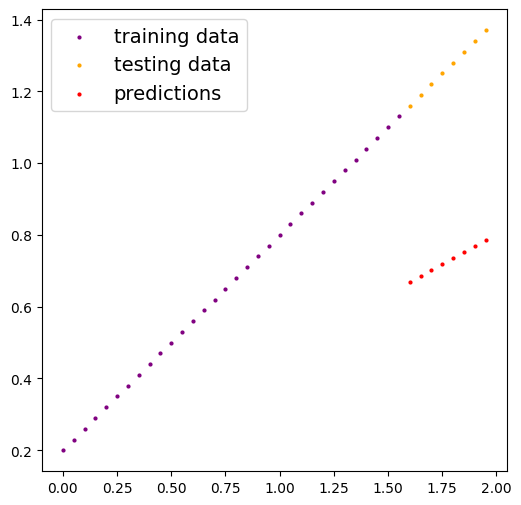

In [15]:
#visualize
plot_prediction(predictions = y_pred)

as we can see the predictions are not at all linear (yellow dots which is our test data) to the trainin' and testin' data (so we need to make it go closer to linear)

## 3. Train model

The whole idea of training is for a model to move from some **unknown parameters** (these may be random) to some **known parameters**.

In other words, training helps the model move from a **poor representation of the data** to a **better representation of the data**.

One way to measure how poor or how wrong a model’s predictions are is by using a **loss function**.

> **Note:** A loss function may also be called a *cost function* or *criterion* in different areas.  
> For our case, we will refer to it as a **loss function**.

---

### Things we need to train

- **Loss Function**  
  A function used to measure how wrong the model’s predictions are compared to the ideal outputs.  
  Lower loss is better.

- **Optimizer**  
  Takes into account the loss of the model and adjusts the model’s parameters  
  (e.g., weights and bias in our case) to improve the loss.

---

### Specifically for PyTorch, we need

- A **training loop**
- A **testing loop**


In [16]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [17]:
# steup a loss function

loss_fn = nn.L1Loss()

#setup an optimizer

optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.01)

note: learning rate is one of the imp hyperparameter(which is set by the ml engineer or data scientist) is very imp cuz it decides how much we gonna adjust the learning eg: if lr=0.1 then it adjust the value say, 0.367 (from first digit(3)) smlarly, if lr=0.001 its from (from third digit(7))

###optimizer
some of the optims are:

*SGD(stocastic gradient descent)

*adam etc...




Q: Which loss function and optimizer should I use?

A: This will be problem specific. But with experience, you'll get an idea of what works and what doesn't with your particular problem set.

For example, for a regression problem (like ours), a loss function of `nn.L1Loss()` and an optimizer like `torch.optim.SGD()` will suffice.

But for a classification problem like classifying whether a photo is of a dog or a cat, you'll likely want to use a loss function of `nn.BCELoss()` (binary cross entropy loss).


## Building a training loop (and a testing loop) in PyTorch

A couple of things we need in a training loop:

0. Loop through the data and
1. Forward pass (this involves data moving through our model's `forward()` functions) to make predictions on data — also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward — move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss (**backpropagation**)
5. Optimizer step — use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**)


In [18]:
torch.manual_seed(42)
#epochs is an hyperparameter that we set which is one loop through the data
epochs = 100
epoch_count = []
train_loss_values = []
test_loss_values = []

##training (as steps above)
#0
for epoch in range(epochs):
  #set model to training mode
  model_0.train()

  #1 forward pass
  train_pred = model_0(X_train)

  #2
  train_loss = loss_fn(train_pred, Y_train)

  #3
  optimizer.zero_grad()

  #4 perform backpropagation on the loss with respect to the parameters of the loop
  train_loss.backward()

  #5
  optimizer.step()
### TESTING
  model_0.eval() #turn off gradient trackin'
  with torch.inference_mode():
    test_pred = model_0(X_test)

    test_loss = loss_fn(test_pred, Y_test)

  #print out what's happenin'
  if epoch % 10 == 0:
    epoch_count.append(epoch)
    train_loss_values.append(train_loss)
    test_loss_values.append(test_loss)
    print(f"epoch: {epoch} | Loss: {train_loss} | Test loss:{test_loss}")
    # print out model state_dict()
    print(model_0.state_dict())



epoch: 0 | Loss: 0.27525559067726135 | Test loss:0.5148090124130249
OrderedDict([('weights', tensor([0.3444])), ('bias', tensor([0.1388]))])
epoch: 10 | Loss: 0.12040016055107117 | Test loss:0.2812182903289795
OrderedDict([('weights', tensor([0.4218])), ('bias', tensor([0.2351]))])
epoch: 20 | Loss: 0.048526376485824585 | Test loss:0.12209327518939972
OrderedDict([('weights', tensor([0.4868])), ('bias', tensor([0.2788]))])
epoch: 30 | Loss: 0.03344954922795296 | Test loss:0.0684521347284317
OrderedDict([('weights', tensor([0.5209])), ('bias', tensor([0.2719]))])
epoch: 40 | Loss: 0.024169567972421646 | Test loss:0.04617038369178772
OrderedDict([('weights', tensor([0.5444])), ('bias', tensor([0.2526]))])
epoch: 50 | Loss: 0.014940948225557804 | Test loss:0.02724619209766388
OrderedDict([('weights', tensor([0.5667])), ('bias', tensor([0.2319]))])
epoch: 60 | Loss: 0.005736829247325659 | Test loss:0.010000824928283691
OrderedDict([('weights', tensor([0.5883])), ('bias', tensor([0.2107]))]

In [19]:
weight,bias

(0.6, 0.2)

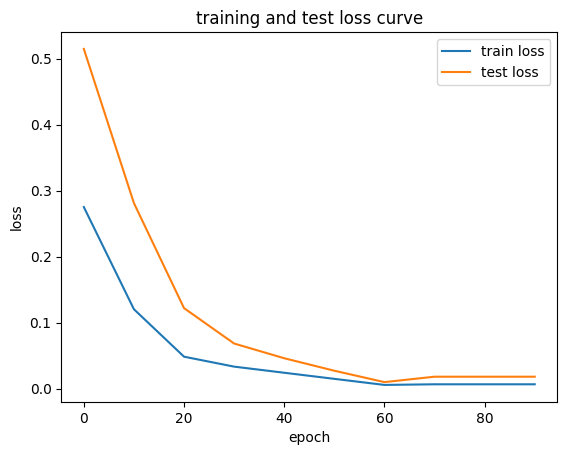

In [20]:
#plotting the loss curves
import numpy as np
plt.plot(epoch_count,np.array(torch.tensor(train_loss_values).numpy()),label= "train loss")
plt.plot(epoch_count,np.array(torch.tensor(test_loss_values).numpy()),label= "test loss")
plt.title("training and test loss curve")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend()


In [21]:
with torch.inference_mode():
  y_pred_new = model_0(X_test)


###BEFORE

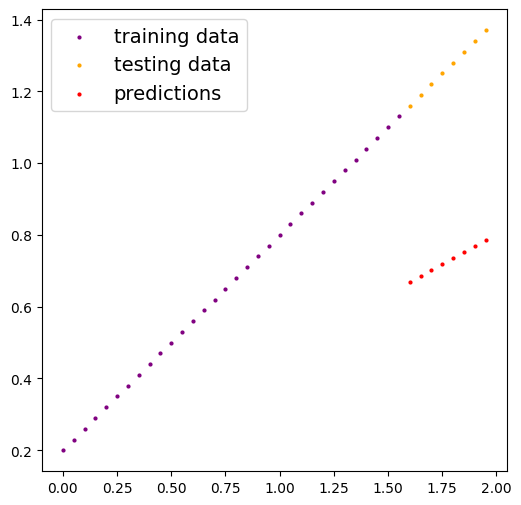

In [22]:
plot_prediction(predictions=y_pred);

###AFTER

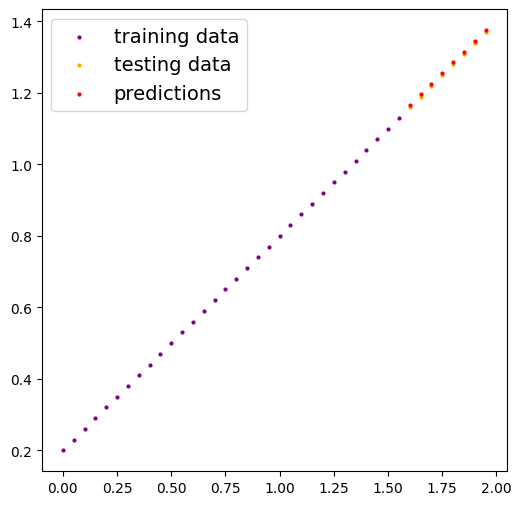

In [23]:
plot_prediction(predictions=y_pred_new);

we got our predictions closer to the target yay!!!
this is cool...(yoo they are literally on the same line) after lot of training btw...